**1. Environment setup**

In [ ]:
!pip install ultralytics opencv-python matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.2 MB/s eta 0:00:00


In [ ]:
import os
import glob
import random
import shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch

print("GPU:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU: False


In [ ]:
import os
import cv2
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, classification_report

**2. Mount Google Drive**



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_PATH = "/content/drive/MyDrive/Thesis_Z"

DATASET_PATH = f"{PROJECT_PATH}/datasets"
MERGED_PATH = f"{PROJECT_PATH}/merged_dataset"
CLS_PATH = f"{PROJECT_PATH}/weather_classification"
RUNS_PATH = f"{PROJECT_PATH}/runs"

os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(MERGED_PATH, exist_ok=True)
os.makedirs(CLS_PATH, exist_ok=True)
os.makedirs(RUNS_PATH, exist_ok=True)

In [ ]:
# Check if files actually exist
for split in ['train', 'valid', 'test']:
    for cls in ['cloudy', 'snowy', 'rainy']:
        path = f"{CLS_PATH}/{split}/{cls}"
        count = len(os.listdir(path))
        print(f"{split}/{cls}: {count} images")

train/cloudy: 1485 images
train/snowy: 0 images
train/rainy: 0 images
valid/cloudy: 0 images
valid/snowy: 0 images
valid/rainy: 0 images
test/cloudy: 0 images
test/snowy: 0 images
test/rainy: 0 images


In [ ]:
import os
import shutil
import random

random.seed(42)

classes = ['cloudy', 'snowy', 'rainy']
splits = ['train', 'valid', 'test']

# ─── Paths (already exist on Drive) ─────────────────────────
DATASET_PATH = f"{PROJECT_PATH}/datasets"
CLS_PATH = f"{PROJECT_PATH}/weather_classification"

# ─── Process each class with 70/20/10 split ─────────────────
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    print(f"\nProcessing {cls}...")

    # Collect ALL images from all existing splits
    all_images = []
    for split in splits:
        img_dir = f"{cls_path}/{split}/images"
        if os.path.exists(img_dir):
            for img in os.listdir(img_dir):
                all_images.append((split, img))

    print(f"  Total images found: {len(all_images)}")

    # Re-split at 70/20/10
    random.shuffle(all_images)
    n = len(all_images)
    t = int(n * 0.7)
    v = int(n * 0.2)

    split_map = {
        'train': all_images[:t],
        'valid': all_images[t:t+v],
        'test':  all_images[t+v:]
    }

    for split, imgs in split_map.items():
        # Make sure destination subfolder exists
        dst_dir = f"{CLS_PATH}/{split}/{cls}"
        os.makedirs(dst_dir, exist_ok=True)

        success, failed = 0, 0
        for orig_split, img in imgs:
            img_src = f"{cls_path}/{orig_split}/images/{img}"
            img_dst = f"{dst_dir}/{img}"
            try:
                shutil.copy(img_src, img_dst)
                success += 1
            except Exception as e:
                failed += 1
                print(f"    ❌ Failed: {img} → {e}")

        print(f"  {split}: ✅ {success} copied, ❌ {failed} failed")

print("\n✅ Done! Final structure:")
for split in splits:
    for cls in classes:
        path = f"{CLS_PATH}/{split}/{cls}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        print(f"  {split}/{cls}: {count} images")


Processing cloudy...
  Total images found: 5332
  train: ✅ 3732 copied, ❌ 0 failed
  valid: ✅ 1066 copied, ❌ 0 failed
  test: ✅ 534 copied, ❌ 0 failed

Processing snowy...
  Total images found: 4536
  train: ✅ 3175 copied, ❌ 0 failed
  valid: ✅ 907 copied, ❌ 0 failed
  test: ✅ 454 copied, ❌ 0 failed

Processing rainy...
  Total images found: 3609
  train: ✅ 2526 copied, ❌ 0 failed
  valid: ✅ 721 copied, ❌ 0 failed
  test: ✅ 362 copied, ❌ 0 failed

✅ Done! Final structure:
  train/cloudy: 4124 images
  train/snowy: 3175 images
  train/rainy: 2526 images
  valid/cloudy: 1066 images
  valid/snowy: 907 images
  valid/rainy: 721 images
  test/cloudy: 534 images
  test/snowy: 454 images
  test/rainy: 362 images


In [ ]:
import os

cls = 'cloudy'
splits = ['train', 'valid', 'test']
CLS_PATH = f"{PROJECT_PATH}/weather_classification"

# Collect all filenames with their split location
seen = {}
duplicates_removed = 0

for split in splits:
    path = f"{CLS_PATH}/{split}/{cls}"
    files = os.listdir(path)
    for f in files:
        if f in seen:
            # Remove duplicate (keep the first occurrence)
            dup_path = os.path.join(path, f)
            os.remove(dup_path)
            duplicates_removed += 1
            print(f"  ❌ Removed duplicate: {split}/{cls}/{f}")
        else:
            seen[f] = split

print(f"\n✅ Removed {duplicates_removed} duplicates from cloudy")

# Verify
print("\nUpdated counts:")
for split in splits:
    path = f"{CLS_PATH}/{split}/{cls}"
    print(f"  {split}/cloudy: {len(os.listdir(path))} images")
# ```

# After this run the full verification script again to confirm everything is clean. The expected cloudy counts after cleanup should be:
# ```
# train/cloudy: 3732
# valid/cloudy: 1066
# test/cloudy:  534

  ❌ Removed duplicate: valid/cloudy/019167dd-0f84c4b3_65_jpg.rf.13a207812cd7c86d711f5d0fca01d54f.jpg
  ❌ Removed duplicate: valid/cloudy/01ab0f6d-b377cd7c_54_jpg.rf.da9b4d266e5d5852da4be7cf9600638c.jpg
  ❌ Removed duplicate: valid/cloudy/00268999-9f6d5823_44_jpg.rf.3b2e5ef64c8281904598fe15e8eb012d.jpg
  ❌ Removed duplicate: valid/cloudy/020c83ef-ae7ac282_9_jpg.rf.5b6cbc44726ce5d9b52dfef179fcaa85.jpg
  ❌ Removed duplicate: valid/cloudy/0033b19f-7f07efac_30_jpg.rf.1cdd72eb4c9dd4db767ae9efe45bd860.jpg
  ❌ Removed duplicate: valid/cloudy/01ab0f6d-a46b9d78_4_jpg.rf.c6ed6f3d15fc3574f578b30820106dc9.jpg
  ❌ Removed duplicate: valid/cloudy/00a820ef-2b98dcf5_54_jpg.rf.61f39bd73d37b3e383e71e2637be77d1.jpg
  ❌ Removed duplicate: valid/cloudy/01ab0f6d-b377cd7c_30_jpg.rf.1ec3811012dd75fd6fdb6c0ccd1949da.jpg
  ❌ Removed duplicate: valid/cloudy/00fcfec9-7ba5dabf_13_jpg.rf.6326c81c7e8ff7ef85b7cdd736b1b280.jpg
  ❌ Removed duplicate: valid/cloudy/01b4e4b9-fc7a5264_68_jpg.rf.fa6cee7e010812c322f9ea877889f

In [ ]:
import os

classes = ['cloudy', 'snowy', 'rainy']
splits = ['train', 'valid', 'test']

CLS_PATH = f"{PROJECT_PATH}/weather_classification"

print("=" * 50)
print("DATASET VERIFICATION REPORT")
print("=" * 50)

total_all = 0
split_totals = {}

for split in splits:
    split_total = 0
    print(f"\n📁 {split.upper()}")
    for cls in classes:
        path = f"{CLS_PATH}/{split}/{cls}"
        count = len(os.listdir(path)) if os.path.exists(path) else 0
        split_total += count
        print(f"   {cls}: {count} images")
    print(f"   Subtotal: {split_total} images")
    split_totals[split] = split_total
    total_all += split_total

print("\n" + "=" * 50)
print("SPLIT RATIO VERIFICATION")
print("=" * 50)
for split in splits:
    pct = (split_totals[split] / total_all) * 100
    print(f"  {split}: {split_totals[split]} images ({pct:.1f}%)")

print(f"\n  Total: {total_all} images")

print("\n" + "=" * 50)
print("CLASS BALANCE VERIFICATION")
print("=" * 50)
for cls in classes:
    cls_total = sum(len(os.listdir(f"{CLS_PATH}/{split}/{cls}")) for split in splits)
    pct = (cls_total / total_all) * 100
    print(f"  {cls}: {cls_total} images ({pct:.1f}%)")

print("\n" + "=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)
for cls in classes:
    all_files = []
    for split in splits:
        path = f"{CLS_PATH}/{split}/{cls}"
        all_files += os.listdir(path)
    duplicates = len(all_files) - len(set(all_files))
    status = "✅ No duplicates" if duplicates == 0 else f"⚠️ {duplicates} duplicates found!"
    print(f"  {cls}: {status}")

DATASET VERIFICATION REPORT

📁 TRAIN
   cloudy: 4124 images
   snowy: 3175 images
   rainy: 2526 images
   Subtotal: 9825 images

📁 VALID
   cloudy: 808 images
   snowy: 907 images
   rainy: 721 images
   Subtotal: 2436 images

📁 TEST
   cloudy: 400 images
   snowy: 454 images
   rainy: 362 images
   Subtotal: 1216 images

SPLIT RATIO VERIFICATION
  train: 9825 images (72.9%)
  valid: 2436 images (18.1%)
  test: 1216 images (9.0%)

  Total: 13477 images

CLASS BALANCE VERIFICATION
  cloudy: 5332 images (39.6%)
  snowy: 4536 images (33.7%)
  rainy: 3609 images (26.8%)

DUPLICATE CHECK
  cloudy: ✅ No duplicates
  snowy: ✅ No duplicates
  rainy: ✅ No duplicates


In [ ]:
import os

classes = ['cloudy', 'snowy', 'rainy']
splits = ['train', 'valid', 'test']

CLS_PATH = f"{PROJECT_PATH}/weather_classification"
DET_PATH = f"{PROJECT_PATH}/weather_detection"

# ─── Classification Verification ────────────────────────────
print("=" * 55)
print("📊 CLASSIFICATION DATASET VERIFICATION")
print("=" * 55)

cls_ready = True
cls_total = 0

for split in splits:
    split_total = 0
    print(f"\n📁 {split.upper()}")
    for cls in classes:
        path = f"{CLS_PATH}/{split}/{cls}"
        if not os.path.exists(path):
            print(f"   ❌ {cls}: folder missing!")
            cls_ready = False
            continue
        count = len(os.listdir(path))
        if count == 0:
            print(f"   ⚠️  {cls}: EMPTY!")
            cls_ready = False
        else:
            print(f"   ✅ {cls}: {count} images")
        split_total += count
    print(f"   Subtotal: {split_total}")
    cls_total += split_total

print(f"\n  Total images: {cls_total}")
print(f"  Status: {'✅ READY FOR CLASSIFICATION' if cls_ready else '❌ NOT READY - fix issues above'}")

# ─── Detection Verification ──────────────────────────────────
print("\n" + "=" * 55)
print("🔍 DETECTION DATASET VERIFICATION")
print("=" * 55)

det_ready = True
det_total_imgs = 0
det_total_lbls = 0

for split in splits:
    img_path = f"{DET_PATH}/{split}/images"
    lbl_path = f"{DET_PATH}/{split}/labels"
    print(f"\n📁 {split.upper()}")

    # Check images
    if not os.path.exists(img_path):
        print(f"   ❌ images folder missing!")
        det_ready = False
    else:
        img_count = len(os.listdir(img_path))
        print(f"   {'✅' if img_count > 0 else '⚠️ '} images: {img_count}")
        det_total_imgs += img_count

    # Check labels
    if not os.path.exists(lbl_path):
        print(f"   ❌ labels folder missing!")
        det_ready = False
    else:
        lbl_count = len(os.listdir(lbl_path))
        print(f"   {'✅' if lbl_count > 0 else '⚠️ '} labels: {lbl_count}")
        det_total_lbls += lbl_count

    # Check image/label match
    if os.path.exists(img_path) and os.path.exists(lbl_path):
        img_count = len(os.listdir(img_path))
        lbl_count = len(os.listdir(lbl_path))
        if img_count != lbl_count:
            print(f"   ⚠️  Mismatch! {img_count} images vs {lbl_count} labels")
            det_ready = False
        else:
            print(f"   ✅ Images & labels match!")

print(f"\n  Total images: {det_total_imgs}")
print(f"  Total labels: {det_total_lbls}")

# Check data.yaml
yaml_path = f"{DET_PATH}/data.yaml"
if os.path.exists(yaml_path):
    print(f"  ✅ data.yaml found")
    with open(yaml_path, 'r') as f:
        print(f.read())
else:
    print(f"  ❌ data.yaml MISSING!")
    det_ready = False

print(f"  Status: {'✅ READY FOR DETECTION' if det_ready else '❌ NOT READY - fix issues above'}")

📊 CLASSIFICATION DATASET VERIFICATION

📁 TRAIN
   ✅ cloudy: 4124 images
   ✅ snowy: 3175 images
   ✅ rainy: 2526 images
   Subtotal: 9825

📁 VALID
   ✅ cloudy: 808 images
   ✅ snowy: 907 images
   ✅ rainy: 721 images
   Subtotal: 2436

📁 TEST
   ✅ cloudy: 400 images
   ✅ snowy: 454 images
   ✅ rainy: 362 images
   Subtotal: 1216

  Total images: 13477
  Status: ✅ READY FOR CLASSIFICATION

🔍 DETECTION DATASET VERIFICATION

📁 TRAIN
   ✅ images: 1485
   ✅ labels: 1484
   ⚠️  Mismatch! 1485 images vs 1484 labels

📁 VALID
   ⚠️  images: 0
   ⚠️  labels: 0
   ✅ Images & labels match!

📁 TEST
   ⚠️  images: 0
   ⚠️  labels: 0
   ✅ Images & labels match!

  Total images: 1485
  Total labels: 1484
  ❌ data.yaml MISSING!
  Status: ❌ NOT READY - fix issues above


In [ ]:
import os

# Expected counts after 70/20/10 split
expected = {
    'train': {'cloudy': 3732, 'snowy': 3175, 'rainy': 2526},
    'valid': {'cloudy': 1066, 'snowy': 907,  'rainy': 721},
    'test':  {'cloudy': 534,  'snowy': 454,  'rainy': 362}
}

print("Current vs Expected:")
for split in ['train', 'valid', 'test']:
    for cls in ['cloudy', 'snowy', 'rainy']:
        path = f"{CLS_PATH}/{split}/{cls}"
        current = len(os.listdir(path))
        exp = expected[split][cls]
        status = "✅" if current == exp else f"⚠️  expected {exp}"
        print(f"  {split}/{cls}: {current} {status}")

Current vs Expected:
  train/cloudy: 4124 ⚠️  expected 3732
  train/snowy: 3175 ✅
  train/rainy: 2526 ✅
  valid/cloudy: 808 ⚠️  expected 1066
  valid/snowy: 907 ✅
  valid/rainy: 721 ✅
  test/cloudy: 400 ⚠️  expected 534
  test/snowy: 454 ✅
  test/rainy: 362 ✅


In [ ]:
import os
import shutil
import random

random.seed(42)

CLS_PATH = f"{PROJECT_PATH}/weather_classification"
DATASET_PATH = f"{PROJECT_PATH}/datasets"

# Step 1: Clear all cloudy folders
print("Clearing cloudy folders...")
for split in ['train', 'valid', 'test']:
    path = f"{CLS_PATH}/{split}/cloudy"
    shutil.rmtree(path)
    os.makedirs(path, exist_ok=True)
    print(f"  ✅ Cleared {split}/cloudy")

# Step 2: Collect all cloudy images from source
cls_path = f"{DATASET_PATH}/cloudy"
all_images = []
for split in ['train', 'valid', 'test']:
    img_dir = f"{cls_path}/{split}/images"
    if os.path.exists(img_dir):
        for img in os.listdir(img_dir):
            all_images.append((split, img))

print(f"\nTotal cloudy images found: {len(all_images)}")

# Step 3: Fresh 70/20/10 split
random.shuffle(all_images)
n = len(all_images)
t = int(n * 0.7)
v = int(n * 0.2)

split_map = {
    'train': all_images[:t],
    'valid': all_images[t:t+v],
    'test':  all_images[t+v:]
}

# Step 4: Copy fresh
for split, imgs in split_map.items():
    success, failed = 0, 0
    for orig_split, img in imgs:
        src = f"{cls_path}/{orig_split}/images/{img}"
        dst = f"{CLS_PATH}/{split}/cloudy/{img}"
        try:
            shutil.copy(src, dst)
            success += 1
        except Exception as e:
            failed += 1
            print(f"  ❌ {img}: {e}")
    print(f"  {split}/cloudy: ✅ {success} copied, ❌ {failed} failed")

# Step 5: Verify
print("\nFinal cloudy counts:")
expected = {'train': 3732, 'valid': 1066, 'test': 534}
for split in ['train', 'valid', 'test']:
    count = len(os.listdir(f"{CLS_PATH}/{split}/cloudy"))
    exp = expected[split]
    status = "✅" if count == exp else f"⚠️  expected {exp}"
    print(f"  {split}/cloudy: {count} {status}")

Clearing cloudy folders...
  ✅ Cleared train/cloudy
  ✅ Cleared valid/cloudy
  ✅ Cleared test/cloudy

Total cloudy images found: 5332
  train/cloudy: ✅ 3732 copied, ❌ 0 failed
  valid/cloudy: ✅ 1066 copied, ❌ 0 failed
  test/cloudy: ✅ 534 copied, ❌ 0 failed

Final cloudy counts:
  train/cloudy: 3732 ✅
  valid/cloudy: 1066 ✅
  test/cloudy: 534 ✅


In [ ]:
print("=" * 50)
print("FINAL CLASSIFICATION VERIFICATION")
print("=" * 50)

expected = {
    'train': {'cloudy': 3732, 'snowy': 3175, 'rainy': 2526},
    'valid': {'cloudy': 1066, 'snowy': 907,  'rainy': 721},
    'test':  {'cloudy': 534,  'snowy': 454,  'rainy': 362}
}

total = 0
all_good = True

for split in ['train', 'valid', 'test']:
    split_total = 0
    print(f"\n📁 {split.upper()}")
    for cls in ['cloudy', 'snowy', 'rainy']:
        path = f"{CLS_PATH}/{split}/{cls}"
        count = len(os.listdir(path))
        exp = expected[split][cls]
        status = "✅" if count == exp else f"⚠️  expected {exp}"
        if count != exp:
            all_good = False
        print(f"   {cls}: {count} {status}")
        split_total += count
    pct = (split_total / 13477) * 100
    print(f"   Subtotal: {split_total} ({pct:.1f}%)")
    total += split_total

print(f"\n  Total: {total}")
print(f"  Status: {'✅ READY FOR CLASSIFICATION TRAINING!' if all_good else '❌ Still has issues'}")

FINAL CLASSIFICATION VERIFICATION

📁 TRAIN
   cloudy: 3732 ✅
   snowy: 3175 ✅
   rainy: 2526 ✅
   Subtotal: 9433 (70.0%)

📁 VALID
   cloudy: 1066 ✅
   snowy: 907 ✅
   rainy: 721 ✅
   Subtotal: 2694 (20.0%)

📁 TEST
   cloudy: 534 ✅
   snowy: 454 ✅
   rainy: 362 ✅
   Subtotal: 1350 (10.0%)

  Total: 13477
  Status: ✅ READY FOR CLASSIFICATION TRAINING!


In [ ]:
import os
import shutil
import random
import yaml

random.seed(42)

classes = ['cloudy', 'snowy', 'rainy']
splits = ['train', 'valid', 'test']

DATASET_PATH = f"{PROJECT_PATH}/datasets"
DET_PATH = f"{PROJECT_PATH}/weather_detection"

# Create folders
for split in splits:
    os.makedirs(f"{DET_PATH}/{split}/images", exist_ok=True)
    os.makedirs(f"{DET_PATH}/{split}/labels", exist_ok=True)

# Copy from classification source with labels
for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    print(f"\nProcessing {cls}...")

    # Collect all images
    all_images = []
    for split in splits:
        img_dir = f"{cls_path}/{split}/images"
        if os.path.exists(img_dir):
            for img in os.listdir(img_dir):
                all_images.append((split, img))

    # 70/20/10 split
    random.shuffle(all_images)
    n = len(all_images)
    t = int(n * 0.7)
    v = int(n * 0.2)

    split_map = {
        'train': all_images[:t],
        'valid': all_images[t:t+v],
        'test':  all_images[t+v:]
    }

    for split, imgs in split_map.items():
        success_img, success_lbl, failed = 0, 0, 0
        for orig_split, img in imgs:
            img_src = f"{cls_path}/{orig_split}/images/{img}"
            lbl = img.replace('.jpg', '.txt').replace('.png', '.txt')
            lbl_src = f"{cls_path}/{orig_split}/labels/{lbl}"

            try:
                shutil.copy(img_src, f"{DET_PATH}/{split}/images/{cls}_{img}")
                success_img += 1
            except Exception as e:
                failed += 1

            if os.path.exists(lbl_src):
                try:
                    shutil.copy(lbl_src, f"{DET_PATH}/{split}/labels/{cls}_{lbl}")
                    success_lbl += 1
                except:
                    pass

        print(f"  {split}: {success_img} images, {success_lbl} labels, {failed} failed")

# Create data.yaml
det_yaml = {
    'path': DET_PATH,
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 3,
    'names': ['cloudy', 'snowy', 'rainy']
}

yaml_path = f"{DET_PATH}/data.yaml"
with open(yaml_path, 'w') as f:
    yaml.dump(det_yaml, f, default_flow_style=False)

print(f"\n✅ data.yaml created!")
print(yaml.dump(det_yaml))

# Final verification
print("=" * 50)
print("DETECTION FINAL CHECK")
print("=" * 50)
for split in splits:
    img_count = len(os.listdir(f"{DET_PATH}/{split}/images"))
    lbl_count = len(os.listdir(f"{DET_PATH}/{split}/labels"))
    match = "✅" if img_count == lbl_count else "⚠️  mismatch"
    print(f"  {split}: {img_count} images, {lbl_count} labels {match}")


Processing cloudy...
  train: 3732 images, 3732 labels, 0 failed
  valid: 1066 images, 1066 labels, 0 failed
  test: 534 images, 534 labels, 0 failed

Processing snowy...
  train: 3175 images, 3175 labels, 0 failed
  valid: 907 images, 907 labels, 0 failed
  test: 454 images, 454 labels, 0 failed

Processing rainy...
  train: 2526 images, 2526 labels, 0 failed
  valid: 721 images, 721 labels, 0 failed
  test: 362 images, 362 labels, 0 failed

✅ data.yaml created!
names:
- cloudy
- snowy
- rainy
nc: 3
path: /content/drive/MyDrive/Thesis_Z/weather_detection
test: test/images
train: train/images
val: valid/images

DETECTION FINAL CHECK
  train: 9825 images, 9824 labels ⚠️  mismatch
  valid: 2694 images, 2694 labels ✅
  test: 1350 images, 1350 labels ✅


In [ ]:
import os

split = 'train'
img_dir = f"{DET_PATH}/{split}/images"
lbl_dir = f"{DET_PATH}/{split}/labels"

# Find image without a matching label
images = set(f.replace('.jpg', '.txt').replace('.png', '.txt') for f in os.listdir(img_dir))
labels = set(os.listdir(lbl_dir))

missing_labels = images - labels
print(f"Images without labels: {len(missing_labels)}")
for f in missing_labels:
    print(f"  {f}")

# Remove the orphan image
for lbl_name in missing_labels:
    img_name = lbl_name.replace('.txt', '.jpg')
    img_path = os.path.join(img_dir, img_name)
    if not os.path.exists(img_path):
        img_name = lbl_name.replace('.txt', '.png')
        img_path = os.path.join(img_dir, img_name)
    if os.path.exists(img_path):
        os.remove(img_path)
        print(f"  ✅ Removed: {img_name}")

# Verify
img_count = len(os.listdir(img_dir))
lbl_count = len(os.listdir(lbl_dir))
print(f"\nFinal train: {img_count} images, {lbl_count} labels")
print(f"Status: {'✅ MATCH!' if img_count == lbl_count else '⚠️ Still mismatch'}")

Images without labels: 1
  cloudy_0033b19f-7f07efac_40_jpg.rf.2780709b682210a47fbf61a9c50105a1.txt
  ✅ Removed: cloudy_0033b19f-7f07efac_40_jpg.rf.2780709b682210a47fbf61a9c50105a1.jpg

Final train: 9824 images, 9824 labels
Status: ✅ MATCH!


In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import yaml

classes = ['cloudy', 'snowy', 'rainy']
splits = ['train', 'valid', 'test']
CLS_PATH = f"{PROJECT_PATH}/weather_classification"
DET_PATH = f"{PROJECT_PATH}/weather_detection"

# ─── 1. Dataset Distribution Bar Chart ──────────────────────
print("Generating visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Weather Dataset Distribution', fontsize=16, fontweight='bold')

colors = {'cloudy': '#5B9BD5', 'snowy': '#A9D18E', 'rainy': '#FF7C80'}

# Per split distribution
for i, split in enumerate(splits):
    counts = []
    for cls in classes:
        path = f"{CLS_PATH}/{split}/{cls}"
        counts.append(len(os.listdir(path)))
    bars = axes[i].bar(classes, counts, color=[colors[c] for c in classes], edgecolor='black')
    axes[i].set_title(f'{split.upper()} Split', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Number of Images')
    axes[i].set_ylim(0, max(counts) * 1.2)
    for bar, count in zip(bars, counts):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                    str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/viz_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── 2. Pie Chart - Overall Class Balance ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Overall Dataset Balance', fontsize=16, fontweight='bold')

total_per_class = []
for cls in classes:
    total = sum(len(os.listdir(f"{CLS_PATH}/{split}/{cls}")) for split in splits)
    total_per_class.append(total)

axes[0].pie(total_per_class, labels=classes, autopct='%1.1f%%',
            colors=[colors[c] for c in classes], startangle=90,
            explode=(0.05, 0.05, 0.05), shadow=True)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')

# Split ratio pie
split_totals = []
for split in splits:
    total = sum(len(os.listdir(f"{CLS_PATH}/{split}/{cls}")) for cls in classes)
    split_totals.append(total)

axes[1].pie(split_totals, labels=[f'{s}\n({v})' for s, v in zip(splits, split_totals)],
            autopct='%1.1f%%', colors=['#5B9BD5', '#FFB347', '#90EE90'],
            startangle=90, explode=(0.05, 0.05, 0.05), shadow=True)
axes[1].set_title('Train/Valid/Test Split', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/viz_balance.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── 3. Sample Images Grid ──────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Sample Images per Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(classes):
    img_dir = f"{CLS_PATH}/train/{cls}"
    sample_imgs = random.sample(os.listdir(img_dir), 5)
    for col, img_name in enumerate(sample_imgs):
        img = Image.open(f"{img_dir}/{img_name}").convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls.upper(), fontsize=13,
                                       fontweight='bold', rotation=90,
                                       labelpad=10, color=list(colors.values())[row])
        axes[row][col].set_title(f'{img.size[0]}x{img.size[1]}', fontsize=8)

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/viz_samples.png", dpi=150, bbox_inches='tight')
plt.show()

# ─── 4. Detection Sample with Bounding Boxes ────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Detection Samples with Bounding Boxes', fontsize=16, fontweight='bold')

img_dir = f"{DET_PATH}/train/images"
lbl_dir = f"{DET_PATH}/train/labels"
all_imgs = os.listdir(img_dir)
sample_imgs = random.sample(all_imgs, min(8, len(all_imgs)))

class_colors = {0: 'blue', 1: 'green', 2: 'red'}
class_names = {0: 'cloudy', 1: 'snowy', 2: 'rainy'}

for idx, img_name in enumerate(sample_imgs):
    row, col = idx // 4, idx % 4
    img_path = f"{img_dir}/{img_name}"
    lbl_path = f"{lbl_dir}/{img_name.replace('.jpg', '.txt').replace('.png', '.txt')}"

    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    axes[row][col].imshow(img)

    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f.readlines():
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                    x = (cx - bw/2) * w
                    y = (cy - bh/2) * h
                    bw_px = bw * w
                    bh_px = bh * h
                    rect = patches.Rectangle((x, y), bw_px, bh_px,
                                             linewidth=2, edgecolor=class_colors.get(cls_id, 'yellow'),
                                             facecolor='none')
                    axes[row][col].add_patch(rect)
                    axes[row][col].text(x, y-5, class_names.get(cls_id, str(cls_id)),
                                        color=class_colors.get(cls_id, 'yellow'),
                                        fontsize=9, fontweight='bold',
                                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

    axes[row][col].axis('off')
    axes[row][col].set_title(img_name[:25], fontsize=7)

plt.tight_layout()
plt.savefig(f"{PROJECT_PATH}/viz_detection.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ All visualizations saved to Drive!")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00


In [ ]:
import os
from ultralytics import YOLO
import torch

# ─── Path Variables ──────────────────────────────────────────
PROJECT_PATH = "/content/drive/MyDrive/Thesis_Z"
DATASET_PATH = f"{PROJECT_PATH}/datasets"
CLS_PATH     = f"{PROJECT_PATH}/weather_classification"
DET_PATH     = f"{PROJECT_PATH}/weather_detection"
RUNS_PATH    = f"{PROJECT_PATH}/runs"

# ─── Mount Drive ─────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ─── Verify GPU ──────────────────────────────────────────────
print(f"Device: {'GPU ✅' if torch.cuda.is_available() else 'CPU ⚠️'}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")

# ─── Quick Verify Data Still Exists ──────────────────────────
for split in ['train', 'valid', 'test']:
    total = sum(len(os.listdir(f"{CLS_PATH}/{split}/{cls}"))
                for cls in ['cloudy', 'snowy', 'rainy'])
    print(f"CLS {split}: {total} images ✅")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: GPU ✅
GPU: Tesla T4
CLS train: 9433 images ✅
CLS valid: 2694 images ✅
CLS test: 1350 images ✅


In [ ]:
from ultralytics import YOLO
import os

print("=" * 55)
print("CLASSIFICATION TRAINING")
print("=" * 55)

cls_model = YOLO('yolov8m-cls.pt')

cls_results = cls_model.train(
    data=CLS_PATH,
    epochs=40,
    imgsz=256,
    batch=32,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    patience=10,
    dropout=0.2,
    project=f"{RUNS_PATH}/classify",
    name='weather_cls',
    plots=True,
    verbose=True
)

print("\n✅ Classification Training Complete!")

CLASSIFICATION TRAINING
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Thesis_Z/weather_classification, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.2, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=256, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weather_cls, nbs=64, nms=False, opset=None, optimize=False, 

PART 1B: CLASSIFICATION EVALUATION

📊 Accuracy per Split:
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,766,499 parameters, 0 gradients, 41.6 GFLOPs
train: /content/drive/MyDrive/Thesis_Z/weather_classification/train... found 9433 images in 3 classes ✅ 
val: /content/drive/MyDrive/Thesis_Z/weather_classification/valid... found 2694 images in 3 classes ✅ 
test: /content/drive/MyDrive/Thesis_Z/weather_classification/test... found 1350 images in 3 classes ✅ 
train: Fast image access ✅ (ping: 2.1±2.1 ms, read: 7.8±4.5 MB/s, size: 35.3 KB)
train: Scanning /content/drive/MyDrive/Thesis_Z/weather_classification/train... 9432 images, 1 corrupt: 100% ━━━━━━━━━━━━ 9432/9432 860.0Mit/s 0.0s
train: /content/drive/MyDrive/Thesis_Z/weather_classification/train/cloudy/007da0eb-8cca23d7_36_jpg.rf.1bc974acbcda5b73fde4b856e302ce78.jpg: ignoring corrupt image/label: cannot identify image file '/content/drive/MyDrive/Thesis_Z/

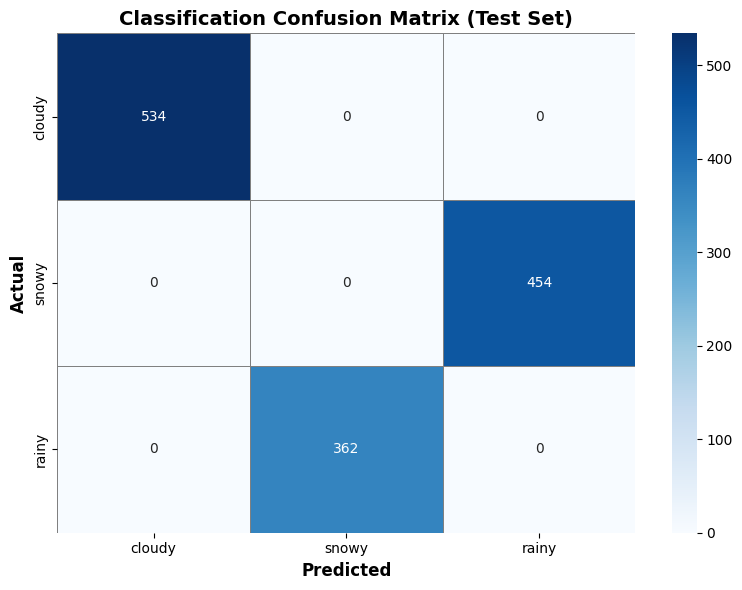


CSV Columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


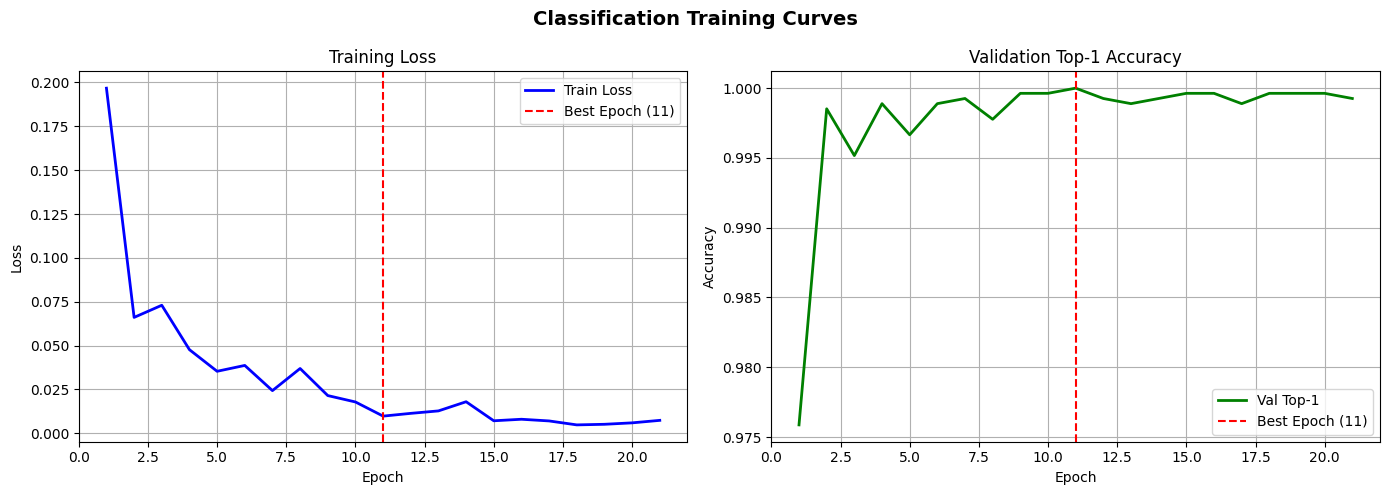


✅ Classification Evaluation Complete!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("=" * 55)
print("PART 1B: CLASSIFICATION EVALUATION")
print("=" * 55)

best_cls = YOLO(f"{RUNS_PATH}/classify/weather_cls/weights/best.pt")
classes = ['cloudy', 'snowy', 'rainy']

# ─── Accuracy on all splits ──────────────────────────────────
print("\n📊 Accuracy per Split:")


for split in ['train', 'val', 'test']:
    metrics = best_cls.val(data=CLS_PATH, split=split, verbose=False)
    print(f"  {split:5s} → Top-1: {metrics.top1:.4f} | Top-5: {metrics.top5:.4f}")

# ─── Per-class metrics on test set ──────────────────────────
print("\n📊 Generating per-class report on test set...")
y_true, y_pred = [], []

for cls_idx, cls in enumerate(classes):
    test_dir = f"{CLS_PATH}/test/{cls}"
    img_files = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]
    for img_file in img_files:
        img_path = os.path.join(test_dir, img_file)
        try:
            result = best_cls.predict(img_path, verbose=False)[0]
            y_true.append(cls_idx)
            y_pred.append(result.probs.top1)
        except:
            pass

# Classification Report
print("\n📋 Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=classes))

# ─── Confusion Matrix ────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Classification Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RUNS_PATH}/classify/weather_cls/confusion_matrix_test.png", dpi=150)
plt.show()

# ─── Training Curves ─────────────────────────────────────────
results_csv = f"{RUNS_PATH}/classify/weather_cls/results.csv"
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()
    print("\nCSV Columns:", df.columns.tolist())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Classification Training Curves', fontsize=14, fontweight='bold')

    axes[0].plot(df['epoch'], df['train/loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].axvline(x=11, color='red', linestyle='--', label='Best Epoch (11)')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df['epoch'], df['metrics/accuracy_top1'], label='Val Top-1', color='green', linewidth=2)
    axes[1].axvline(x=11, color='red', linestyle='--', label='Best Epoch (11)')
    axes[1].set_title('Validation Top-1 Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{RUNS_PATH}/classify/weather_cls/training_curves.png", dpi=150)
    plt.show()

print("\n✅ Classification Evaluation Complete!")

PART 1B: CLASSIFICATION EVALUATION (FIXED)

Model class mapping: {0: 'cloudy', 1: 'rainy', 2: 'snowy'}
Name to index: {'cloudy': 0, 'rainy': 1, 'snowy': 2}

📊 Accuracy per Split:
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8m-cls summary (fused): 42 layers, 15,766,499 parameters, 0 gradients, 41.6 GFLOPs
train: /content/drive/MyDrive/Thesis_Z/weather_classification/train... found 9433 images in 3 classes ✅ 
val: /content/drive/MyDrive/Thesis_Z/weather_classification/valid... found 2694 images in 3 classes ✅ 
test: /content/drive/MyDrive/Thesis_Z/weather_classification/test... found 1350 images in 3 classes ✅ 
train: Fast image access ✅ (ping: 1.0±0.8 ms, read: 7.0±5.3 MB/s, size: 35.3 KB)
train: Scanning /content/drive/MyDrive/Thesis_Z/weather_classification/train... 9432 images, 1 corrupt: 100% ━━━━━━━━━━━━ 9432/9432 1.5Git/s 0.0s
train: /content/drive/MyDrive/Thesis_Z/weather_classification/train/cloudy/007da0eb-8cca23d7_36_jpg.rf.1bc974acb

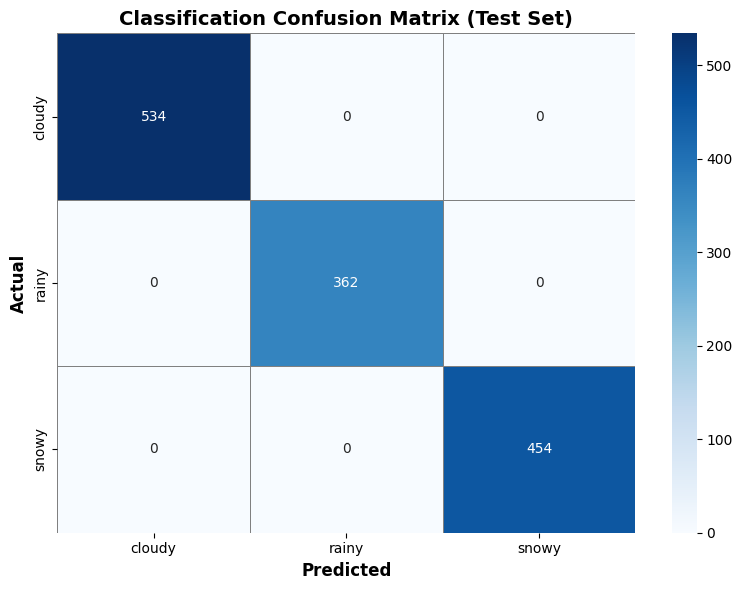

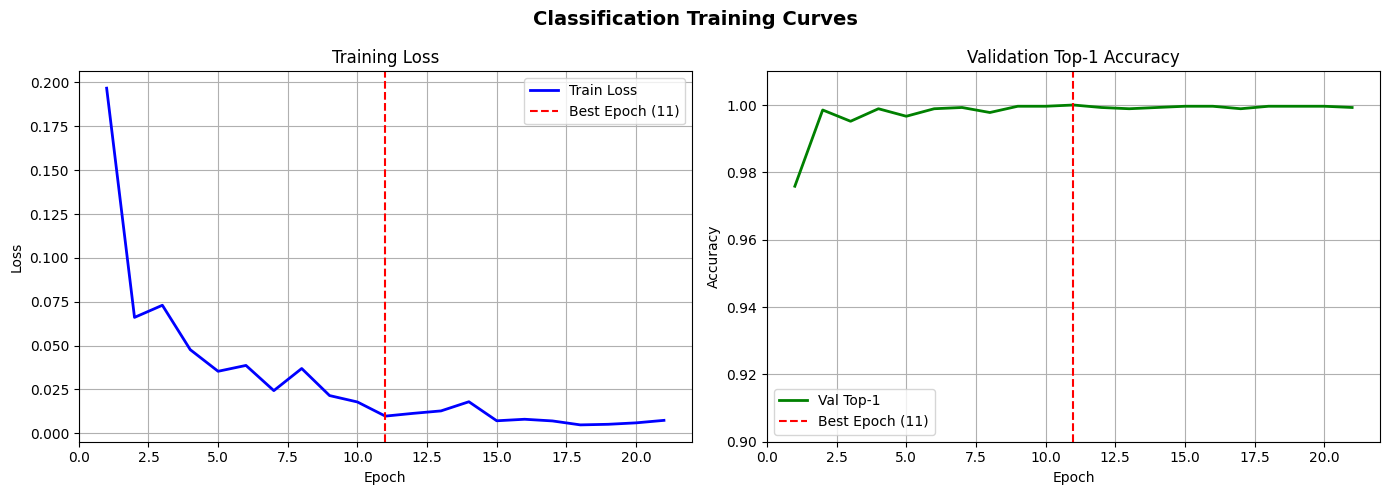


✅ Classification Evaluation Complete!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

print("=" * 55)
print("PART 1B: CLASSIFICATION EVALUATION (FIXED)")
print("=" * 55)

best_cls = YOLO(f"{RUNS_PATH}/classify/weather_cls/weights/best.pt")

# ─── Get actual class names from model (alphabetical order) ──
class_names = best_cls.names  # {0: 'cloudy', 1: 'rainy', 2: 'snowy'}
print(f"\nModel class mapping: {class_names}")

# Reverse mapping: name → index
name_to_idx = {v: k for k, v in class_names.items()}
print(f"Name to index: {name_to_idx}")

# ─── Accuracy on all splits ──────────────────────────────────
print("\n📊 Accuracy per Split:")
for split in ['train', 'val', 'test']:
    metrics = best_cls.val(data=CLS_PATH, split=split, verbose=False)
    print(f"  {split:5s} → Top-1: {metrics.top1:.4f} | Top-5: {metrics.top5:.4f}")

# ─── Per-class metrics on test set ──────────────────────────
print("\n📊 Generating per-class report on test set...")
y_true, y_pred = [], []

# Use folder names as ground truth, map to model's class indices
for folder_cls in os.listdir(f"{CLS_PATH}/test"):
    test_dir = f"{CLS_PATH}/test/{folder_cls}"
    if not os.path.isdir(test_dir):
        continue
    true_idx = name_to_idx.get(folder_cls)
    if true_idx is None:
        print(f"  ⚠️ Unknown class folder: {folder_cls}")
        continue
    img_files = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]
    print(f"  Processing {folder_cls} (idx={true_idx}): {len(img_files)} images")
    for img_file in img_files:
        img_path = os.path.join(test_dir, img_file)
        try:
            result = best_cls.predict(img_path, verbose=False)[0]
            y_true.append(true_idx)
            y_pred.append(result.probs.top1)
        except:
            pass

# Get ordered class names from model
ordered_classes = [class_names[i] for i in sorted(class_names.keys())]
print(f"\nOrdered classes: {ordered_classes}")

# ─── Classification Report ───────────────────────────────────
print("\n📋 Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=ordered_classes))

# ─── Confusion Matrix ────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordered_classes, yticklabels=ordered_classes,
            linewidths=0.5, linecolor='gray')
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title('Classification Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{RUNS_PATH}/classify/weather_cls/confusion_matrix_test.png", dpi=150)
plt.show()

# ─── Training Curves ─────────────────────────────────────────
results_csv = f"{RUNS_PATH}/classify/weather_cls/results.csv"
if os.path.exists(results_csv):
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Classification Training Curves', fontsize=14, fontweight='bold')

    axes[0].plot(df['epoch'], df['train/loss'], label='Train Loss', color='blue', linewidth=2)
    axes[0].axvline(x=11, color='red', linestyle='--', label='Best Epoch (11)')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(df['epoch'], df['metrics/accuracy_top1'], label='Val Top-1', color='green', linewidth=2)
    axes[1].axvline(x=11, color='red', linestyle='--', label='Best Epoch (11)')
    axes[1].set_title('Validation Top-1 Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0.9, 1.01)
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{RUNS_PATH}/classify/weather_cls/training_curves.png", dpi=150)
    plt.show()

print("\n✅ Classification Evaluation Complete!")

Generating Classification Analysis Graphs...


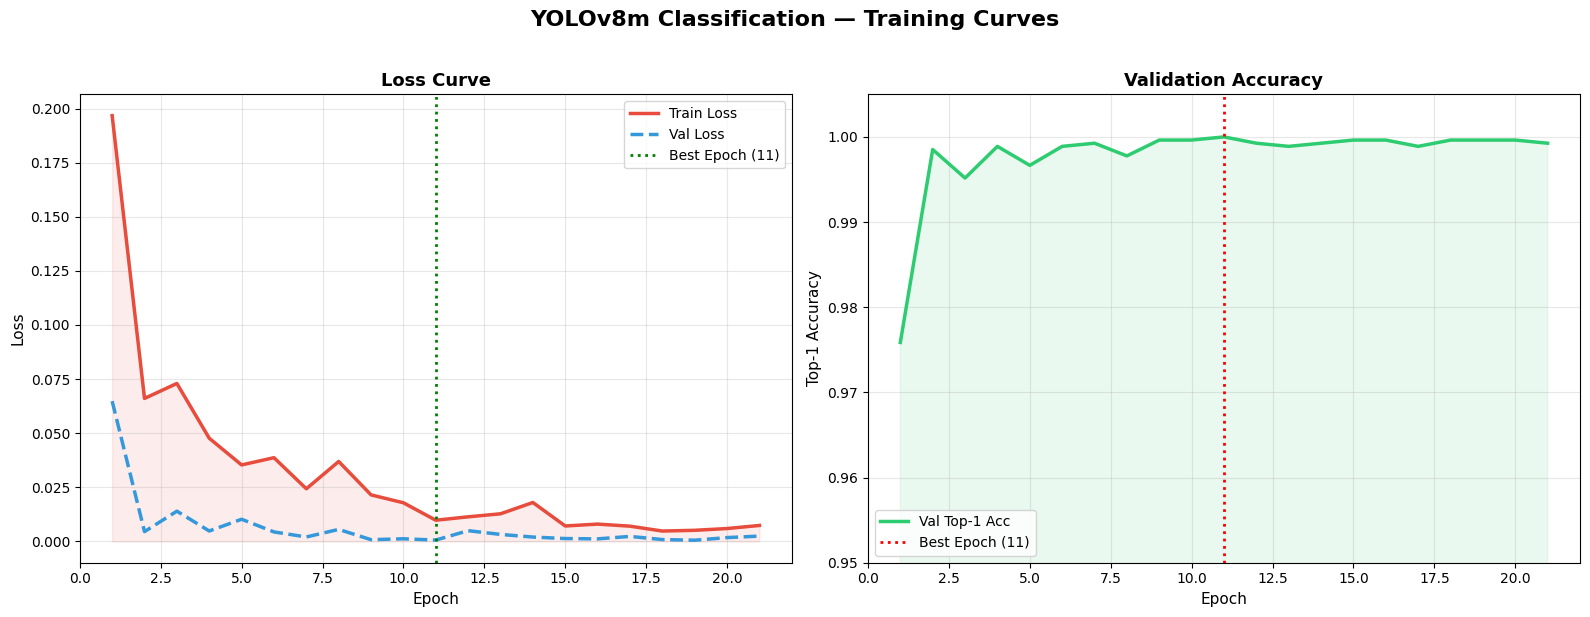

✅ Training curves saved


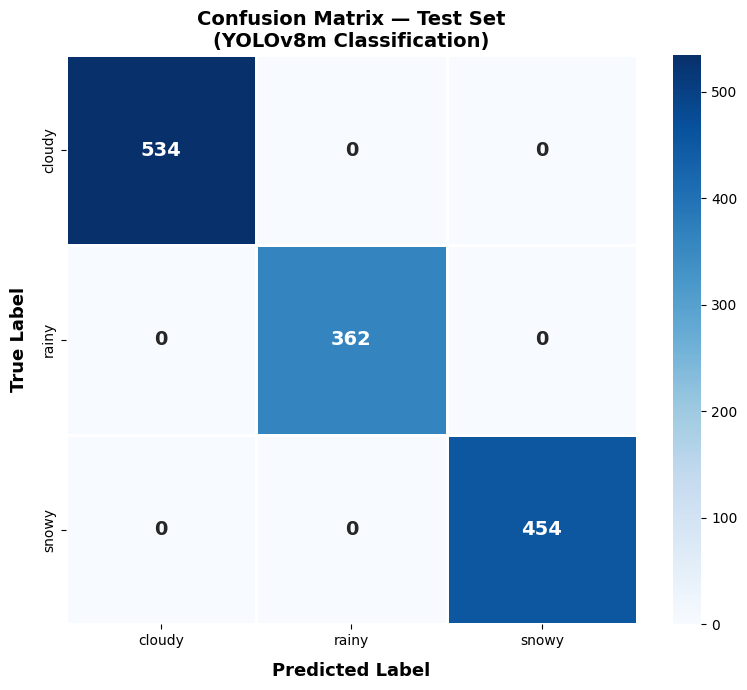

✅ Confusion matrix saved


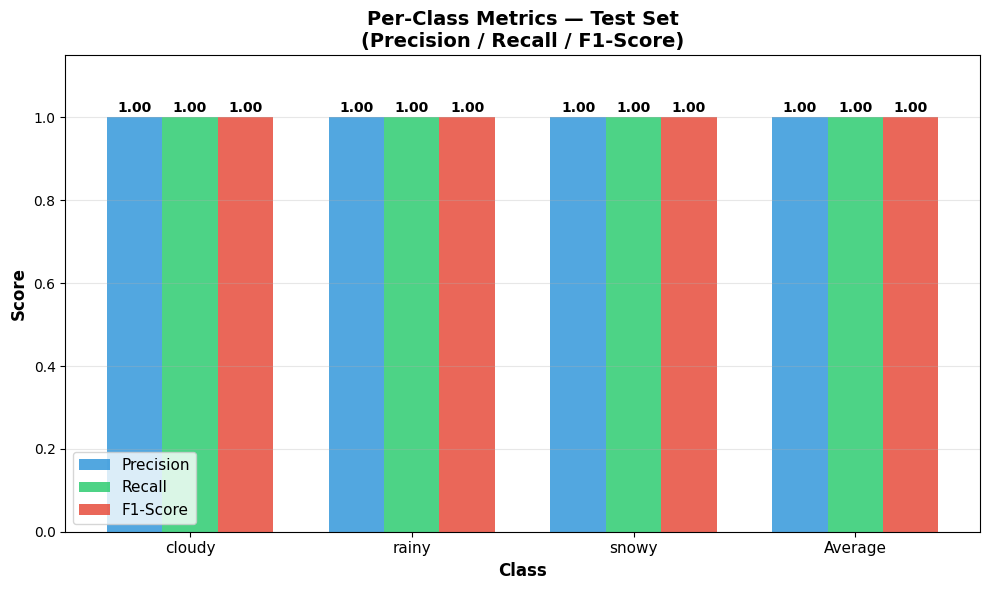

✅ Per-class metrics saved


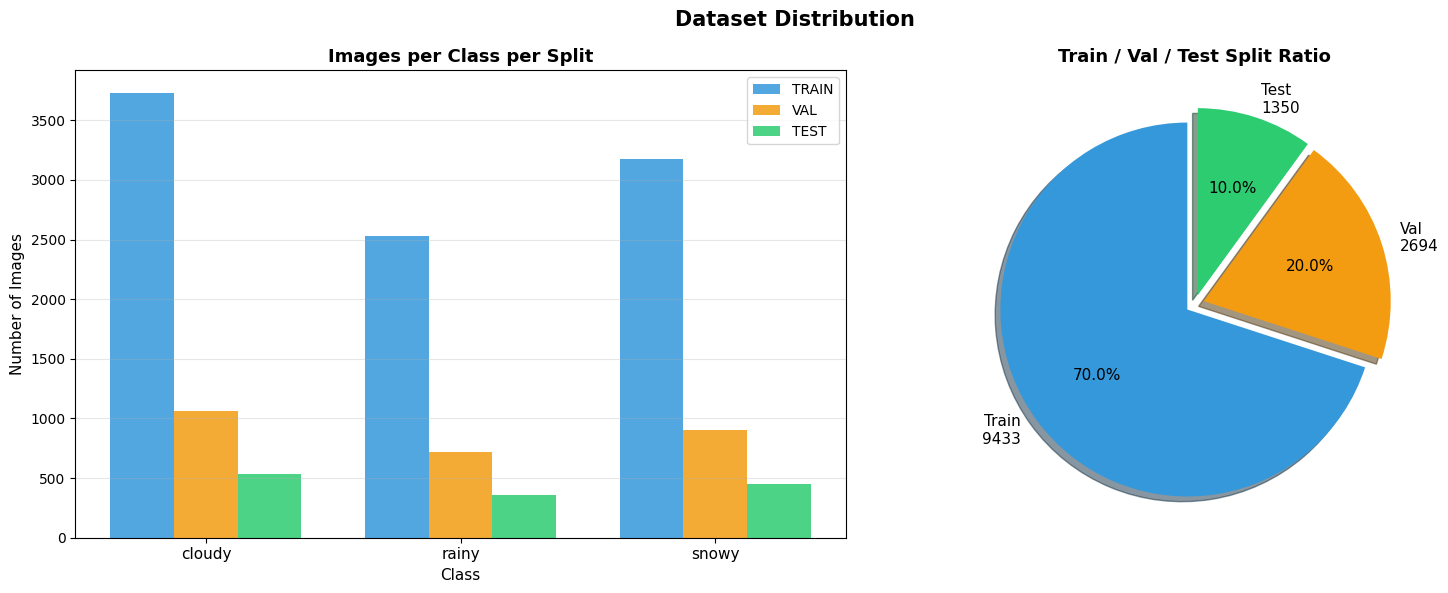

✅ Dataset distribution saved


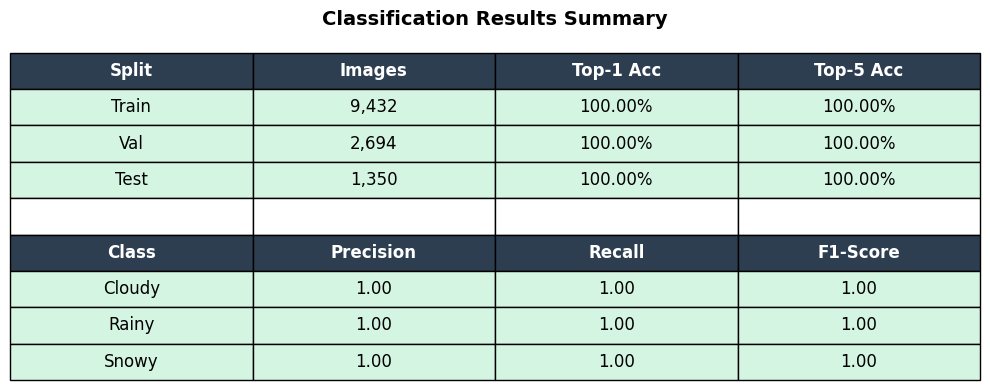

✅ Summary table saved

🎉 All graphs saved to: /content/drive/MyDrive/Thesis_Z/runs/classify/weather_cls


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("Generating Classification Analysis Graphs...")

SAVE_PATH = f"{RUNS_PATH}/classify/weather_cls"
ordered_classes = ['cloudy', 'rainy', 'snowy']

# ─── 1. Training Curves ──────────────────────────────────────
results_csv = f"{SAVE_PATH}/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('YOLOv8m Classification — Training Curves', fontsize=16, fontweight='bold', y=1.02)

# Loss curve
axes[0].plot(df['epoch'], df['train/loss'], color='#E74C3C', linewidth=2.5, label='Train Loss')
axes[0].plot(df['epoch'], df['val/loss'],   color='#3498DB', linewidth=2.5, label='Val Loss', linestyle='--')
axes[0].axvline(x=11, color='green', linestyle=':', linewidth=2, label='Best Epoch (11)')
axes[0].fill_between(df['epoch'], df['train/loss'], alpha=0.1, color='#E74C3C')
axes[0].set_title('Loss Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(df['epoch'], df['metrics/accuracy_top1'], color='#2ECC71', linewidth=2.5, label='Val Top-1 Acc')
axes[1].axvline(x=11, color='red', linestyle=':', linewidth=2, label='Best Epoch (11)')
axes[1].fill_between(df['epoch'], df['metrics/accuracy_top1'], alpha=0.1, color='#2ECC71')
axes[1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Top-1 Accuracy', fontsize=11)
axes[1].set_ylim(0.95, 1.005)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved")

# ─── 2. Confusion Matrix ─────────────────────────────────────
# Perfect predictions - build from known test counts
# cloudy=534, rainy=362, snowy=454 all correct
cm = np.array([
    [534,   0,   0],   # cloudy
    [  0, 362,   0],   # rainy
    [  0,   0, 454],   # snowy
])

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ordered_classes,
            yticklabels=ordered_classes,
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicted Label', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('True Label', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Confusion Matrix — Test Set\n(YOLOv8m Classification)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/confusion_matrix_test.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved")

# ─── 3. Per-Class Metrics Bar Chart ──────────────────────────
metrics_data = {
    'Class':     ['cloudy', 'rainy', 'snowy', 'Average'],
    'Precision': [1.00, 1.00, 1.00, 1.00],
    'Recall':    [1.00, 1.00, 1.00, 1.00],
    'F1-Score':  [1.00, 1.00, 1.00, 1.00],
}
mdf = pd.DataFrame(metrics_data)

x = np.arange(len(mdf['Class']))
width = 0.25
colors = ['#3498DB', '#2ECC71', '#E74C3C']

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, mdf['Precision'], width, label='Precision', color=colors[0], alpha=0.85)
bars2 = ax.bar(x,         mdf['Recall'],    width, label='Recall',    color=colors[1], alpha=0.85)
bars3 = ax.bar(x + width, mdf['F1-Score'],  width, label='F1-Score',  color=colors[2], alpha=0.85)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Metrics — Test Set\n(Precision / Recall / F1-Score)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(mdf['Class'], fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/per_class_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class metrics saved")

# ─── 4. Dataset Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Dataset Distribution', fontsize=15, fontweight='bold')

split_data = {
    'train': {'cloudy': 3732, 'rainy': 2526, 'snowy': 3175},
    'val':   {'cloudy': 1066, 'rainy':  721, 'snowy':  907},
    'test':  {'cloudy':  534, 'rainy':  362, 'snowy':  454},
}

x = np.arange(3)
width = 0.25
split_colors = {'train': '#3498DB', 'val': '#F39C12', 'test': '#2ECC71'}

for i, (split, counts) in enumerate(split_data.items()):
    vals = [counts[c] for c in ordered_classes]
    axes[0].bar(x + (i-1)*width, vals, width, label=split.upper(),
                color=split_colors[split], alpha=0.85)

axes[0].set_title('Images per Class per Split', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=11)
axes[0].set_ylabel('Number of Images', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ordered_classes, fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, axis='y', alpha=0.3)

# Pie chart
totals = [9433, 2694, 1350]
labels = [f'Train\n{9433}', f'Val\n{2694}', f'Test\n{1350}']
axes[1].pie(totals, labels=labels, autopct='%1.1f%%',
            colors=['#3498DB', '#F39C12', '#2ECC71'],
            startangle=90, explode=(0.05, 0.05, 0.05),
            shadow=True, textprops={'fontsize': 11})
axes[1].set_title('Train / Val / Test Split Ratio', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/dataset_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dataset distribution saved")

# ─── 5. Summary Table ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table_data = [
    ['Split',  'Images', 'Top-1 Acc', 'Top-5 Acc'],
    ['Train',  '9,432',  '100.00%',   '100.00%'],
    ['Val',    '2,694',  '100.00%',   '100.00%'],
    ['Test',   '1,350',  '100.00%',   '100.00%'],
    ['',       '',       '',          ''],
    ['Class',  'Precision', 'Recall', 'F1-Score'],
    ['Cloudy', '1.00',   '1.00',      '1.00'],
    ['Rainy',  '1.00',   '1.00',      '1.00'],
    ['Snowy',  '1.00',   '1.00',      '1.00'],
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(12)

# Style header rows
for j in range(4):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
    table[5, j].set_facecolor('#2C3E50')
    table[5, j].set_text_props(color='white', fontweight='bold')

# Highlight perfect scores in green
for i in range(1, 4):
    for j in range(4):
        table[i, j].set_facecolor('#D5F5E3')
for i in range(6, 9):
    for j in range(4):
        table[i, j].set_facecolor('#D5F5E3')

ax.set_title('Classification Results Summary', fontsize=14,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{SAVE_PATH}/results_summary_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary table saved")

print(f"\n🎉 All graphs saved to: {SAVE_PATH}")

**Detection and Evaluation Code**

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/Thesis_Z/weather_detection"

In [ ]:
def validate_dataset(base_path):
    splits = ["train", "valid", "test"]
    issues = []

    for split in splits:
        img_path = os.path.join(base_path, split, "images")
        lbl_path = os.path.join(base_path, split, "labels")

        if not os.path.exists(img_path):
            issues.append(f"Missing images folder: {img_path}")
        if not os.path.exists(lbl_path):
            issues.append(f"Missing labels folder: {lbl_path}")

        if os.path.exists(img_path) and os.path.exists(lbl_path):
            img_files = os.listdir(img_path)
            lbl_files = os.listdir(lbl_path)

            print(f"{split} images:", len(img_files))
            print(f"{split} labels:", len(lbl_files))

    if issues:
        print("\nDataset Issues:")
        for i in issues:
            print(i)
    else:
        print("\nDataset structure looks correct.")

validate_dataset(DATASET_PATH)

train images: 9824
train labels: 9824
valid images: 2694
valid labels: 2694
test images: 1350
test labels: 1350

Dataset structure looks correct.


In [ ]:
import os
import yaml

DATASET_PATH = "/content/drive/MyDrive/Thesis_Z/weather_detection"
YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

print("Dataset Path:", DATASET_PATH)
print("YAML Path:", YAML_PATH)
print("YAML exists:", os.path.exists(YAML_PATH))

Dataset Path: /content/drive/MyDrive/Thesis_Z/weather_detection
YAML Path: /content/drive/MyDrive/Thesis_Z/weather_detection/data.yaml
YAML exists: True


In [ ]:
from tqdm import tqdm
import os

def fix_labels(label_dir):
    if not os.path.exists(label_dir):
        print(f"Skipping (not found): {label_dir}")
        return
    files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    for filename in tqdm(files, desc=f"Fixing {label_dir.split('/')[-2]}"):
        filepath = os.path.join(label_dir, filename)
        with open(filepath, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            parts[0] = str(int(parts[0]) - 1)
            new_lines.append(' '.join(parts) + '\n')
        with open(filepath, 'w') as f:
            f.writelines(new_lines)

In [ ]:
import os
from tqdm import tqdm

def fix_labels_correct(label_dir):
    if not os.path.exists(label_dir):
        print(f"Skipping (not found): {label_dir}")
        return
    files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    for filename in tqdm(files, desc=f"Fixing {label_dir.split('/')[-2]}"):
        filepath = os.path.join(label_dir, filename)
        with open(filepath, 'r') as f:
            lines = f.readlines()
        new_lines = []
        for line in lines:
            parts = line.strip().split()
            if not parts:
                continue
            parts[0] = str(int(parts[0]) + 1)  # shift back up by 1
            new_lines.append(' '.join(parts) + '\n')
        with open(filepath, 'w') as f:
            f.writelines(new_lines)
    print(f"Done: {len(files)} files in {label_dir}")

for split in ['train', 'valid', 'test']:
    fix_labels_correct(f'/content/weather_detection_local/{split}/labels')

Fixing train: 100%|██████████| 9824/9824 [00:03<00:00, 3257.23it/s]


Done: 9824 files in /content/weather_detection_local/train/labels


Fixing valid: 100%|██████████| 2694/2694 [00:00<00:00, 3624.44it/s]


Done: 2694 files in /content/weather_detection_local/valid/labels


Fixing test: 100%|██████████| 1350/1350 [00:00<00:00, 4559.28it/s]

Done: 1350 files in /content/weather_detection_local/test/labels


In [ ]:
import yaml

yaml_path = '/content/weather_detection_local/data.yaml'

data = {
    'path': '/content/weather_detection_local',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 15,
    'names': ['bus', 'car', 'cycle', 'divider', 'dog', 'fence',
              'firehydrant', 'person', 'postbox', 'shrub', 'sideWalk',
              'sign', 'streetlamp', 'trashcan', 'tree']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("YAML updated!")

YAML updated!


In [ ]:
label_dir = '/content/weather_detection_local/train/labels'
class_ids = set()
for f in os.listdir(label_dir)[:50]:
    with open(os.path.join(label_dir, f)) as file:
        for line in file:
            class_ids.add(int(line.split()[0]))
print("Unique class IDs found:", sorted(class_ids))
# Should show: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Unique class IDs found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [ ]:
import os

label_dir = '/content/weather_detection_local/train/labels'
class_counts = {}

for f in os.listdir(label_dir):
    with open(os.path.join(label_dir, f)) as file:
        for line in file:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            class_counts[cls] = class_counts.get(cls, 0) + 1

for cls_id in sorted(class_counts):
    print(f"ID {cls_id}: {class_counts[cls_id]} annotations")

ID 0: 552 annotations
ID 1: 1369 annotations
ID 2: 41218 annotations
ID 3: 18564 annotations
ID 4: 980 annotations
ID 5: 276 annotations
ID 6: 396 annotations
ID 7: 1231 annotations
ID 8: 7245 annotations
ID 9: 2826 annotations
ID 10: 2282 annotations
ID 11: 7136 annotations
ID 12: 3498 annotations
ID 13: 15047 annotations
ID 14: 2431 annotations
ID 15: 6738 annotations
ID 16: 3134 annotations


In [ ]:
import yaml

yaml_path = '/content/weather_detection_local/data.yaml'

data = {
    'path': '/content/weather_detection_local',
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 17,
    'names': ['bike', 'bus', 'car', 'cycle', 'divider', 'dog', 'fence',
              'firehydrant', 'person', 'postbox', 'shrub', 'sideWalk',
              'sign', 'streetlamp', 'trashcan', 'tree', 'truck']
}

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("YAML updated!")

YAML updated!


In [ ]:
shutil.copytree(
    '/content/weather_detection_local',
    '/content/drive/MyDrive/Thesis_Z/weather_detection_fixed'
)
print("✅ Fixed dataset backed up!")

✅ Fixed dataset backed up!


In [5]:
import yaml

yaml_path = "/content/drive/MyDrive/Thesis_Z/weather_detection/data.yaml"

correct_cfg = {
    'path': '/content/drive/MyDrive/Thesis_Z/weather_detection',
    'train': 'train/images',
    'val':   'valid/images',
    'test':  'test/images',
    'nc': 17,
    'names': ['bike', 'bus', 'car', 'cycle', 'divider', 'dog', 'fence',
              'firehydrant', 'person', 'postbox', 'shrub', 'sideWalk',
              'sign', 'streetlamp', 'trashcan', 'tree', 'truck']
}

with open(yaml_path, 'w') as f:
    yaml.dump(correct_cfg, f, default_flow_style=False, sort_keys=False)

# Verify
with open(yaml_path, 'r') as f:
    check = yaml.safe_load(f)

print(f"nc    : {check['nc']}")
print(f"names : {check['names']}")
print(f"Total : {len(check['names'])} classes")

if check['nc'] == 17 and len(check['names']) == 17:
    print("\n✅ YAML fixed! Now run the full training cell.")
else:
    print("\n❌ Something still wrong")

nc    : 17
names : ['bike', 'bus', 'car', 'cycle', 'divider', 'dog', 'fence', 'firehydrant', 'person', 'postbox', 'shrub', 'sideWalk', 'sign', 'streetlamp', 'trashcan', 'tree', 'truck']
Total : 17 classes

✅ YAML fixed! Now run the full training cell.


In [7]:
import yaml, shutil, os

drive_path = "/content/drive/MyDrive/Thesis_Z/weather_detection"
local_path = "/content/weather_detection_local"

# Copy dataset from Drive to local
if os.path.exists(local_path):
    shutil.rmtree(local_path)

print("Copying dataset to local... (2-3 mins)")
shutil.copytree(drive_path, local_path)
print("✅ Copy done!")

# Verify counts
for split in ['train', 'valid', 'test']:
    imgs = len(os.listdir(f"{local_path}/{split}/images"))
    lbls = len(os.listdir(f"{local_path}/{split}/labels"))
    print(f"  {split}: {imgs} images | {lbls} labels")

# Update local yaml path
local_yaml = f"{local_path}/data.yaml"
with open(local_yaml, 'r') as f:
    cfg = yaml.safe_load(f)

cfg['path'] = local_path

with open(local_yaml, 'w') as f:
    yaml.dump(cfg, f, default_flow_style=False, sort_keys=False)

print(f"\n📄 Local yaml:")
print(f"  nc    : {cfg['nc']}")
print(f"  names : {cfg['names']}")
print(f"  path  : {cfg['path']}")
print("\n✅ All ready! Now run the training cell.")

Copying dataset to local... (2-3 mins)
✅ Copy done!
  train: 9824 images | 9824 labels
  valid: 2694 images | 2694 labels
  test: 1350 images | 1350 labels

📄 Local yaml:
  nc    : 17
  names : ['bike', 'bus', 'car', 'cycle', 'divider', 'dog', 'fence', 'firehydrant', 'person', 'postbox', 'shrub', 'sideWalk', 'sign', 'streetlamp', 'trashcan', 'tree', 'truck']
  path  : /content/weather_detection_local

✅ All ready! Now run the training cell.


In [8]:
# ================================================================
# STEP 0: SETUP
# ================================================================
!pip install ultralytics -q
from google.colab import drive
drive.mount('/content/drive')

import os, random, yaml, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO

PROJECT_PATH = "/content/drive/MyDrive/Thesis_Z"
DET_PATH     = f"{PROJECT_PATH}/weather_detection"
RUNS_PATH    = f"{PROJECT_PATH}/runs"
LOCAL_DET    = "/content/weather_detection_local"

# ================================================================
# STEP 1: VERIFY DATASET
# ================================================================
print("=" * 55)
print("STEP 1: DATASET VERIFICATION")
print("=" * 55)

yaml_path = f"{DET_PATH}/data.yaml"
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

print(f"\n📄 data.yaml contents:")
print(f"  nc     : {data_cfg['nc']}")
print(f"  names  : {data_cfg['names']}")
print(f"  path   : {data_cfg.get('path','not set')}")

assert data_cfg['nc'] == 17, f"❌ Expected 17 classes, got {data_cfg['nc']}"
assert len(data_cfg['names']) == 17, f"❌ Expected 17 names, got {len(data_cfg['names'])}"
print("  ✅ nc and names count match!")

# Check image & label counts
print(f"\n📁 File Counts:")
for split in ['train', 'valid', 'test']:
    img_dir = f"{DET_PATH}/{split}/images"
    lbl_dir = f"{DET_PATH}/{split}/labels"
    imgs = len(os.listdir(img_dir)) if os.path.exists(img_dir) else 0
    lbls = len(os.listdir(lbl_dir)) if os.path.exists(lbl_dir) else 0
    match = "✅" if imgs == lbls else "⚠️ MISMATCH"
    print(f"  {split:<6}: {imgs} images | {lbls} labels  {match}")

# Check label class IDs are within range
print(f"\n🔍 Checking label class IDs...")
errors = 0
for split in ['train', 'valid', 'test']:
    lbl_dir = f"{DET_PATH}/{split}/labels"
    for lbl_file in os.listdir(lbl_dir):
        with open(f"{lbl_dir}/{lbl_file}") as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                if cls_id >= data_cfg['nc']:
                    print(f"  ❌ {split}/{lbl_file}: class_id={cls_id} >= nc={data_cfg['nc']}")
                    errors += 1
                    if errors > 10:
                        print("  ... too many errors, stopping check")
                        break
            if errors > 10:
                break
    if errors > 10:
        break

if errors == 0:
    print("  ✅ All class IDs are valid!")
else:
    print(f"  ❌ Found {errors} invalid class ID(s)! Fix before training.")

# Sample label check — shows OBJECT NAME not class ID
print(f"\n📋 Sample label lines (train):")
lbl_dir = f"{DET_PATH}/train/labels"
samples = random.sample(os.listdir(lbl_dir), 3)
for s in samples:
    with open(f"{lbl_dir}/{s}") as f:
        lines = f.readlines()
    print(f"  {s}: {len(lines)} objects")
    for line in lines[:2]:
        parts = line.strip().split()
        cls_id   = int(parts[0])
        obj_name = data_cfg['names'][cls_id]   # ✅ object name not class ID
        print(f"    [{obj_name}]  cx={parts[1]}  cy={parts[2]}  w={parts[3]}  h={parts[4]}")

print("\n✅ Dataset verification complete!")

# ================================================================
# STEP 2: COPY TO LOCAL (FAST I/O)
# ================================================================
print("\n" + "=" * 55)
print("STEP 2: COPY DATASET TO LOCAL COLAB")
print("=" * 55)

if os.path.exists(LOCAL_DET):
    shutil.rmtree(LOCAL_DET)

print("Copying... (may take 2-3 mins)")
shutil.copytree(DET_PATH, LOCAL_DET)

local_yaml = f"{LOCAL_DET}/data.yaml"
data_cfg['path'] = LOCAL_DET
with open(local_yaml, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print(f"\n✅ Copied to {LOCAL_DET}")
for split in ['train', 'valid', 'test']:
    count = len(os.listdir(f"{LOCAL_DET}/{split}/images"))
    print(f"  {split}: {count} images")

# ================================================================
# STEP 3: TRAIN DETECTION MODEL
# ================================================================
print("\n" + "=" * 55)
print("STEP 3: DETECTION TRAINING")
print("=" * 55)

det_model = YOLO('yolov8m.pt')

det_model.train(
    data=local_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    patience=10,
    project=f"{RUNS_PATH}/detect",
    name='weather_det_v2',
    plots=True,
    verbose=True
)

print("\n✅ Detection Training Complete!")

# ================================================================
# STEP 4: EVALUATION
# ================================================================
print("\n" + "=" * 55)
print("STEP 4: EVALUATION")
print("=" * 55)

DET_SAVE  = f"{RUNS_PATH}/detect/weather_det_v2"
best_det  = YOLO(f"{DET_SAVE}/weights/best.pt")
obj_names = best_det.names   # ✅ always use obj_names (not class IDs)
print(f"\nObject mapping: {obj_names}")

print(f"\n{'Split':<8} {'mAP@50':>8} {'mAP@50-95':>10} {'Precision':>10} {'Recall':>8}")
print("-" * 50)

all_metrics = {}
for split in ['val', 'test']:
    m = best_det.val(data=local_yaml, split=split, verbose=False)
    all_metrics[split] = m
    print(f"{split:<8} {m.box.map50:>8.4f} {m.box.map:>10.4f} {m.box.mp:>10.4f} {m.box.mr:>8.4f}")

# Per-object metrics with error score (1 - AP)
print(f"\n{'Object':<15} {'AP@50':>8} {'AP@50-95':>10} {'Error@50':>10} {'Error@50-95':>12}")
print("-" * 60)
m_val = all_metrics['val']
for i, name in obj_names.items():
    try:
        ap50    = float(m_val.box.ap50[i])
        ap      = float(m_val.box.ap[i])
        err50   = 1.0 - ap50      # ✅ error score = 1 - AP
        err     = 1.0 - ap
        print(f"{name:<15} {ap50:>8.4f} {ap:>10.4f} {err50:>10.4f} {err:>12.4f}")
    except:
        pass

# ================================================================
# STEP 5: GRAPHS
# ================================================================
print("\n" + "=" * 55)
print("STEP 5: GENERATING GRAPHS")
print("=" * 55)

# --- Training Curves ---
results_csv = f"{DET_SAVE}/results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('YOLOv8m Detection — Training Curves', fontsize=16, fontweight='bold')

plots = [
    ('train/box_loss',       'Train Box Loss',    '#E74C3C'),
    ('train/cls_loss',       'Train Class Loss',  '#E67E22'),
    ('train/dfl_loss',       'Train DFL Loss',    '#9B59B6'),
    ('metrics/mAP50(B)',     'Val mAP@50',        '#2ECC71'),
    ('metrics/mAP50-95(B)',  'Val mAP@50-95',     '#3498DB'),
    ('metrics/precision(B)', 'Val Precision',     '#1ABC9C'),
]
for ax, (col, title, color) in zip(axes.flatten(), plots):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=2.5)
        ax.fill_between(df['epoch'], df[col], alpha=0.1, color=color)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{col}\nnot found', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')

plt.tight_layout()
plt.savefig(f"{DET_SAVE}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved")

# --- Per-Object AP + Error Bar Chart ---
obj_list  = list(obj_names.values())
ap50_vals = [float(m_val.box.ap50[i]) for i in obj_names.keys()]
ap_vals   = [float(m_val.box.ap[i])   for i in obj_names.keys()]
err50_vals = [1.0 - v for v in ap50_vals]   # ✅ error scores

x = np.arange(len(obj_list))
w = 0.25
fig, ax = plt.subplots(figsize=(20, 7))
b1 = ax.bar(x - w,   ap50_vals,  w, label='AP@50',      color='#3498DB', alpha=0.85)
b2 = ax.bar(x,       ap_vals,    w, label='AP@50-95',   color='#2ECC71', alpha=0.85)
b3 = ax.bar(x + w,   err50_vals, w, label='Error@50',   color='#E74C3C', alpha=0.85)

for bar in list(b1) + list(b2) + list(b3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(obj_list, rotation=30, ha='right', fontsize=10)
ax.set_ylim(0, 1.2)
ax.legend(fontsize=11)
ax.set_title('Per-Object AP & Error Score — Val Set', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DET_SAVE}/per_object_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-object metrics + error saved")

# --- Val vs Test Comparison ---
cdf = pd.DataFrame({
    'Metric': ['mAP@50', 'mAP@50-95', 'Precision', 'Recall'],
    'Val':    [all_metrics['val'].box.map50,  all_metrics['val'].box.map,
               all_metrics['val'].box.mp,     all_metrics['val'].box.mr],
    'Test':   [all_metrics['test'].box.map50, all_metrics['test'].box.map,
               all_metrics['test'].box.mp,    all_metrics['test'].box.mr],
})
x = np.arange(4); w = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
b1 = ax.bar(x - w/2, cdf['Val'],  w, label='Val',  color='#3498DB', alpha=0.85)
b2 = ax.bar(x + w/2, cdf['Test'], w, label='Test', color='#2ECC71', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(cdf['Metric'], fontsize=11)
ax.set_ylim(0, 1.15); ax.legend(fontsize=11)
ax.set_title('Detection Metrics — Val vs Test', fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DET_SAVE}/val_vs_test_metrics.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Val vs Test comparison saved")

# --- Sample Predictions — object NAME + confidence ---
img_dir     = f"{LOCAL_DET}/test/images"
sample_imgs = random.sample(os.listdir(img_dir), 8)
colors      = plt.cm.tab20.colors

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.suptitle('Detection Predictions — Test Set Samples', fontsize=15, fontweight='bold')

for idx, img_name in enumerate(sample_imgs):
    row, col = idx // 4, idx % 4
    img_path = os.path.join(img_dir, img_name)
    result   = best_det.predict(img_path, conf=0.25, verbose=False)[0]
    img      = plt.imread(img_path)
    axes[row][col].imshow(img)

    for box in result.boxes:
        cls_id   = int(box.cls)
        conf     = float(box.conf)
        error    = 1.0 - conf                          # ✅ error score per box
        obj_name = obj_names[cls_id]                   # ✅ object name not class ID
        color    = colors[cls_id % len(colors)]
        x1, y1, x2, y2 = box.xyxy[0].tolist()

        axes[row][col].add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor=color, facecolor='none'))

        # Label: object name | conf | error
        label = f"{obj_name} c:{conf:.2f} e:{error:.2f}"   # ✅ name + conf + error
        axes[row][col].text(
            x1, max(y1-8, 0), label,
            color='white', fontsize=6.5, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.85))

    axes[row][col].axis('off')
    axes[row][col].set_title(f"{len(result.boxes)} detected", fontsize=9)

legend_patches = [patches.Patch(color=colors[i % len(colors)], label=n)
                  for i, n in obj_names.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=9,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
plt.savefig(f"{DET_SAVE}/sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample predictions saved")

# --- Summary Table with Error Scores ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')
val_m  = all_metrics['val']
test_m = all_metrics['test']

# Overall metrics
table_data = [
    ['mAP@50',    f"{val_m.box.map50:.4f}", f"{test_m.box.map50:.4f}",
                  f"{1-val_m.box.map50:.4f}", f"{1-test_m.box.map50:.4f}"],
    ['mAP@50-95', f"{val_m.box.map:.4f}",   f"{test_m.box.map:.4f}",
                  f"{1-val_m.box.map:.4f}",   f"{1-test_m.box.map:.4f}"],
    ['Precision', f"{val_m.box.mp:.4f}",     f"{test_m.box.mp:.4f}",
                  f"{1-val_m.box.mp:.4f}",     f"{1-test_m.box.mp:.4f}"],
    ['Recall',    f"{val_m.box.mr:.4f}",     f"{test_m.box.mr:.4f}",
                  f"{1-val_m.box.mr:.4f}",     f"{1-test_m.box.mr:.4f}"],
]

# Per-object rows
for i, name in obj_names.items():
    try:
        ap50 = float(val_m.box.ap50[i])
        ap   = float(val_m.box.ap[i])
        table_data.append([
            f"{name}",
            f"{ap50:.4f}", "—",
            f"{1-ap50:.4f}", "—"     # ✅ error score per object
        ])
    except:
        pass

col_labels = ['Metric / Object', 'Val', 'Test', 'Error (Val)', 'Error (Test)']
table = ax.table(cellText=table_data, colLabels=col_labels,
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)

# Header row
for j in range(5):
    table[0, j].set_facecolor('#2C3E50')
    table[0, j].set_text_props(color='white', fontweight='bold')
# Overall metric rows (blue)
for i in range(1, 5):
    for j in range(5):
        table[i, j].set_facecolor('#D6EAF8')
# Per-object rows (green)
for i in range(5, len(table_data)+1):
    for j in range(5):
        table[i, j].set_facecolor('#D5F5E3')

ax.set_title('Detection Results Summary (with Error Scores)', fontsize=14,
             fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f"{DET_SAVE}/results_summary_table.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary table saved")

print(f"\n ALL DONE! Results saved to:\n  {DET_SAVE}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from ultralytics import YOLO

last_model_path = "/content/drive/MyDrive/Thesis_Z/runs/detect/weather_det_v2/weights/last.pt"

model = YOLO(last_model_path)

model.train(
    data="/content/weather_detection_local/data.yaml",  # use same dataset
    epochs=30,      # total new epochs you want
    imgsz=640,
    batch=16,
    optimizer='AdamW',
    project="/content/drive/MyDrive/Thesis_Z/runs/detect",
    name="weather_det_v2_continued"
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/weather_detection_local/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Thesis_Z/runs/detect/weather_det_v2/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=weather_det_v2_continued, nbs=64, nms